<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Correlation**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis (EDA). You will examine the distribution of the data, identify outliers, and determine the correlation between different columns in the dataset.


## Objectives


In this lab, you will perform the following:


- Identify the distribution of compensation data in the dataset.

- Remove outliers to refine the dataset.

- Identify correlations between various features in the dataset.


## Hands on Lab


##### Step 1: Install and Import Required Libraries


In [1]:
# Install the necessary libraries
!pip install pandas
!pip install matplotlib
!pip install seaborn

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Step 2: Load the Dataset


In [2]:
# Load the dataset from the given URL
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# Display the first few rows to understand the structure of the dataset
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 3: Analyze and Visualize Compensation Distribution</h3>


**Task**: Plot the distribution and histogram for `ConvertedCompYearly` to examine the spread of yearly compensation among respondents.


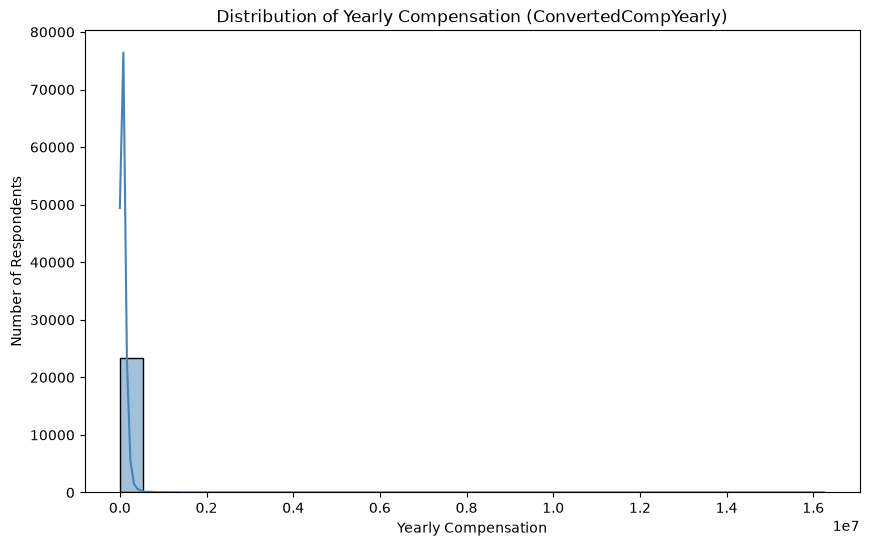

In [3]:
# Remove missing values
comp_data = df['ConvertedCompYearly'].dropna()

# Plot histogram with density curve
plt.figure(figsize=(10, 6))
sns.histplot(comp_data, bins=30, kde=True, color='steelblue')

plt.title('Distribution of Yearly Compensation (ConvertedCompYearly)')
plt.xlabel('Yearly Compensation')
plt.ylabel('Number of Respondents')

plt.show()

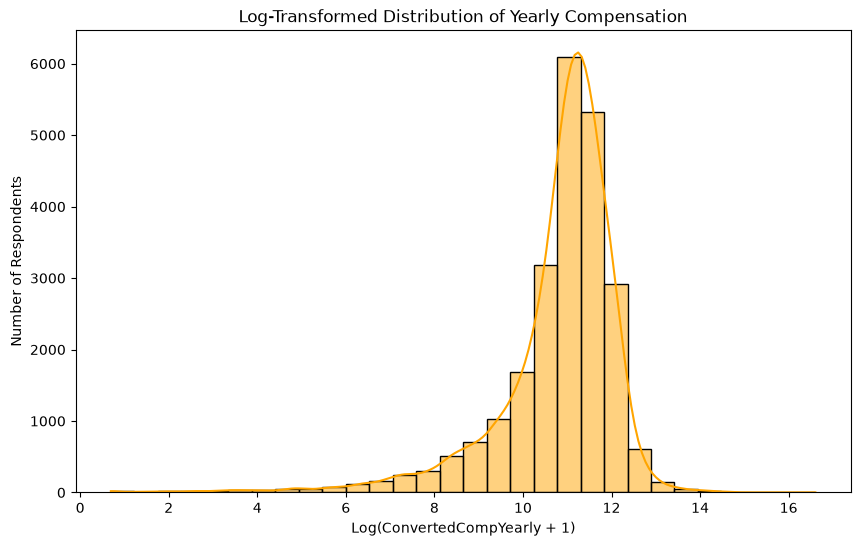

In [4]:
import numpy as np

plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(comp_data), bins=30, kde=True, color='orange')

plt.title('Log-Transformed Distribution of Yearly Compensation')
plt.xlabel('Log(ConvertedCompYearly + 1)')
plt.ylabel('Number of Respondents')

plt.show()

<h3>Step 4: Calculate Median Compensation for Full-Time Employees</h3>


**Task**: Filter the data to calculate the median compensation for respondents whose employment status is "Employed, full-time."


In [5]:
# Filter for full-time employed respondents
full_time = df[df['Employment'] == 'Employed, full-time']

# Calculate median compensation
median_comp = full_time['ConvertedCompYearly'].median()

print("Median yearly compensation for full-time employees:", median_comp)

Median yearly compensation for full-time employees: 69814.0

<h3>Step 5: Analyzing Compensation Range and Distribution by Country</h3>


Explore the range of compensation in the ConvertedCompYearly column by analyzing differences across countries. Use box plots to compare the compensation distributions for each country to identify variations and anomalies within each region, providing insights into global compensation trends.



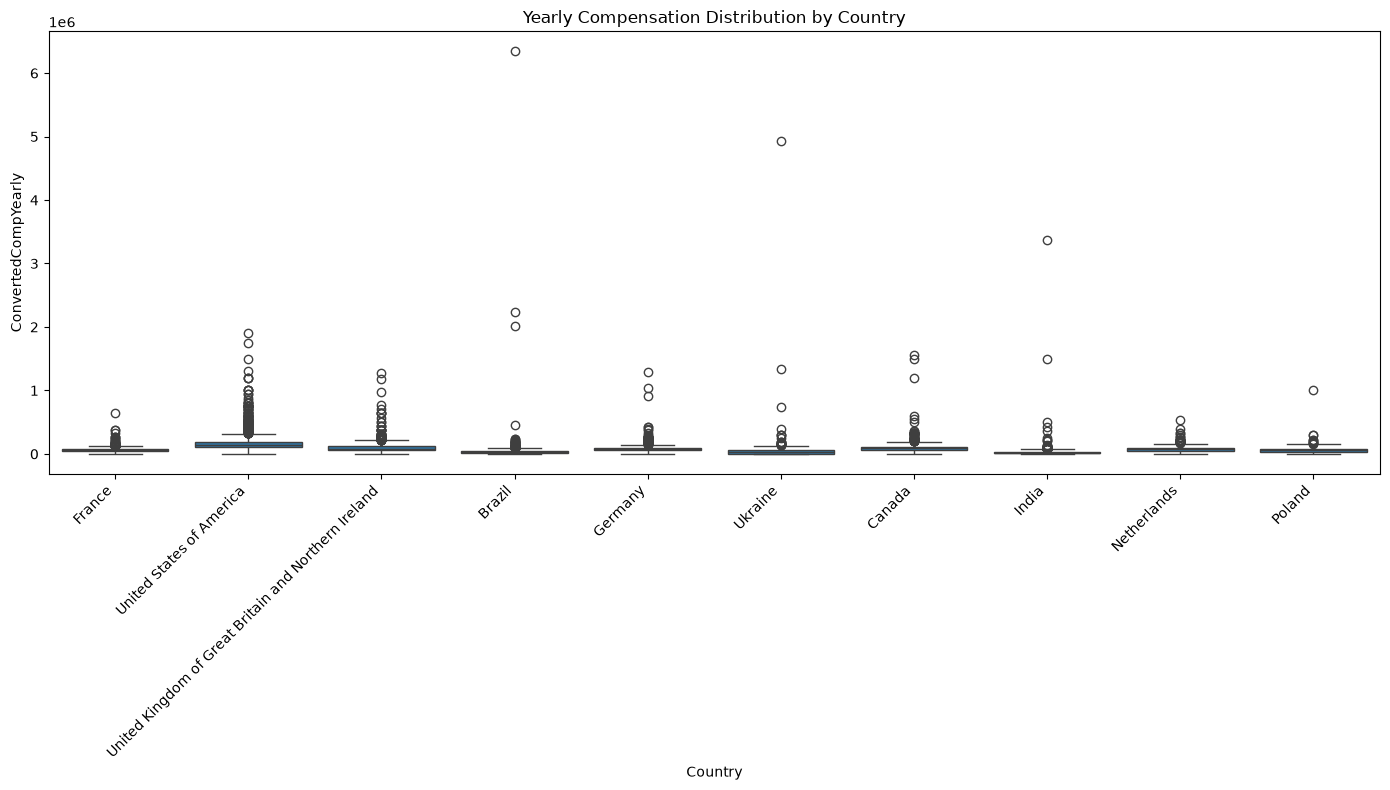

In [6]:
# Remove missing values
country_comp = df[['Country', 'ConvertedCompYearly']].dropna()

# Select top 10 countries by number of respondents
top_countries = country_comp['Country'].value_counts().head(10).index

# Filter data
country_comp_top = country_comp[country_comp['Country'].isin(top_countries)]

# Create box plot
plt.figure(figsize=(14, 8))
sns.boxplot(
    data=country_comp_top,
    x='Country',
    y='ConvertedCompYearly'
)

plt.xticks(rotation=45, ha='right')
plt.title('Yearly Compensation Distribution by Country')
plt.xlabel('Country')
plt.ylabel('ConvertedCompYearly')

plt.tight_layout()
plt.show()

<h3>Step 6: Removing Outliers from the Dataset</h3>


**Task**: Create a new DataFrame by removing outliers from the `ConvertedCompYearly` column to get a refined dataset for correlation analysis.


Lower Bound: -80177.25
Upper Bound: 220860.75

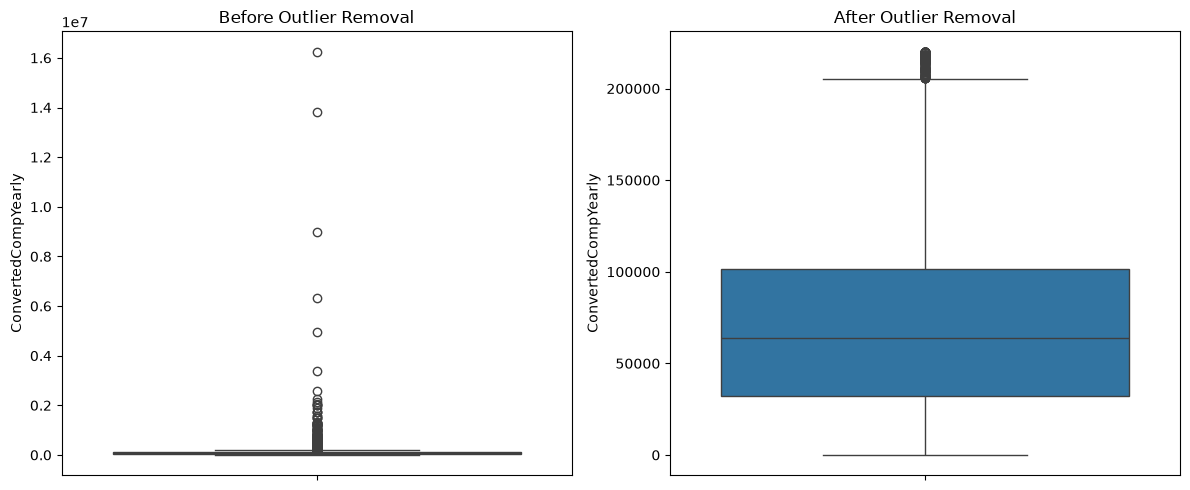

In [7]:
# Calculate Q1, Q3, and IQR
Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)

IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

df_no_outliers = df[
    (df['ConvertedCompYearly'] >= lower_bound) &
    (df['ConvertedCompYearly'] <= upper_bound)
].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df['ConvertedCompYearly'], ax=axes[0])
axes[0].set_title('Before Outlier Removal')

sns.boxplot(y=df_no_outliers['ConvertedCompYearly'], ax=axes[1])
axes[1].set_title('After Outlier Removal')

plt.tight_layout()
plt.show()

<h3>Step 7: Finding Correlations Between Key Variables</h3>


**Task**: Calculate correlations between `ConvertedCompYearly`, `WorkExp`, and `JobSatPoints_1`. Visualize these correlations with a heatmap.


                     ConvertedCompYearly   WorkExp  JobSatPoints_1
ConvertedCompYearly             1.000000  0.406993       -0.059643
WorkExp                         0.406993  1.000000       -0.032388
JobSatPoints_1                 -0.059643 -0.032388        1.000000

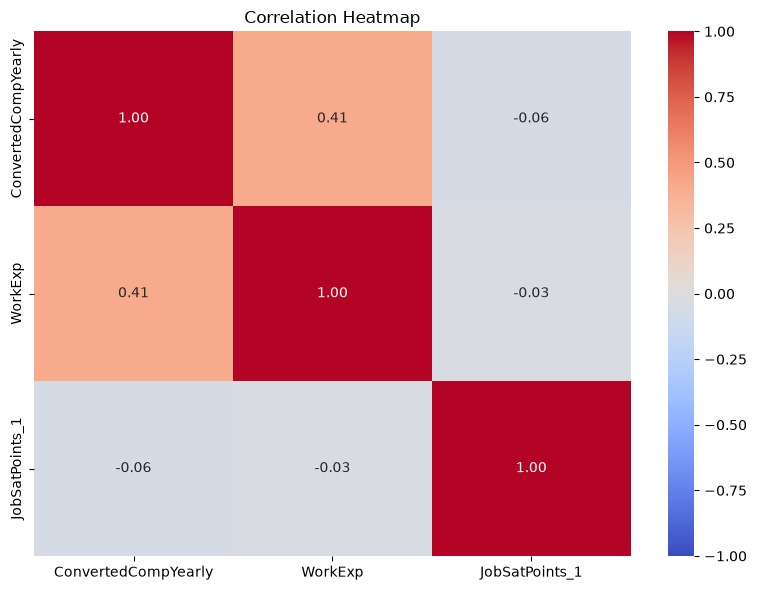

In [8]:
# Select the variables of interest
corr_data = df_no_outliers[
    ['ConvertedCompYearly', 'WorkExp', 'JobSatPoints_1']
].copy()

# Remove rows with missing values in these columns
corr_data = corr_data.dropna()

# Calculate correlation matrix
corr_matrix = corr_data.corr(method='pearson')

# Display correlation values
print(corr_matrix)

# Create heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,
    vmax=1
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

<h3>Step 8: Scatter Plot for Correlations</h3>


**Task**: Create scatter plots to examine specific correlations between `ConvertedCompYearly` and `WorkExp`, as well as between `ConvertedCompYearly` and `JobSatPoints_1`.


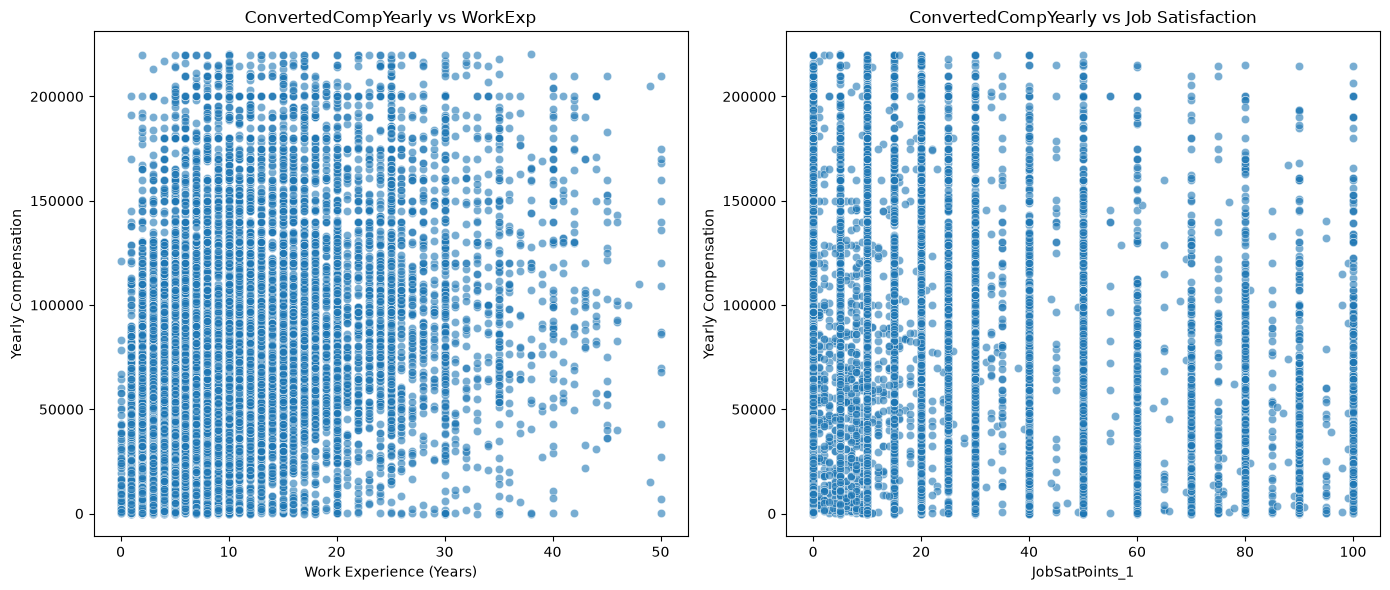

In [9]:
# Keep only required columns and remove missing values
scatter_data = df_no_outliers[
    ['ConvertedCompYearly', 'WorkExp', 'JobSatPoints_1']
].dropna()

# Create side-by-side scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Compensation vs Work Experience
sns.scatterplot(
    data=scatter_data,
    x='WorkExp',
    y='ConvertedCompYearly',
    alpha=0.6,
    ax=axes[0]
)

axes[0].set_title('ConvertedCompYearly vs WorkExp')
axes[0].set_xlabel('Work Experience (Years)')
axes[0].set_ylabel('Yearly Compensation')

# Compensation vs Job Satisfaction
sns.scatterplot(
    data=scatter_data,
    x='JobSatPoints_1',
    y='ConvertedCompYearly',
    alpha=0.6,
    ax=axes[1]
)

axes[1].set_title('ConvertedCompYearly vs Job Satisfaction')
axes[1].set_xlabel('JobSatPoints_1')
axes[1].set_ylabel('Yearly Compensation')

plt.tight_layout()
plt.show()

<h3>Summary</h3>


In this lab, you practiced essential skills in correlation analysis by:

- Examining the distribution of yearly compensation with histograms and box plots.
- Detecting and removing outliers from compensation data.
- Calculating correlations between key variables such as compensation, work experience, and job satisfaction.
- Visualizing relationships with scatter plots and heatmaps to gain insights into the associations between these features.

By following these steps, you have developed a solid foundation for analyzing relationships within the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
